In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import numpy as np
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from utils.evaluation import evaluate_pipeline
from utils import column_type_split, feature_importance_df
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("../data/train_clear.csv")

In [3]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [4]:
columns = column_type_split(X)

In [5]:
def get_pipeline(model) -> Pipeline:
    return Pipeline(
        [
            (
                "preprocess",
                ColumnTransformer(
                    [
                        (
                            "ordinal",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                dtype=np.int64,
                            ),
                            columns.categorical,
                        )
                    ],
                    remainder="passthrough",
                ),
            ),
            (model.__class__.__name__, model),
        ]
    )

Модель BernoulliNB
F1-macro: 0.464 ± 0.003
F1-weighted: 0.561 ± 0.001


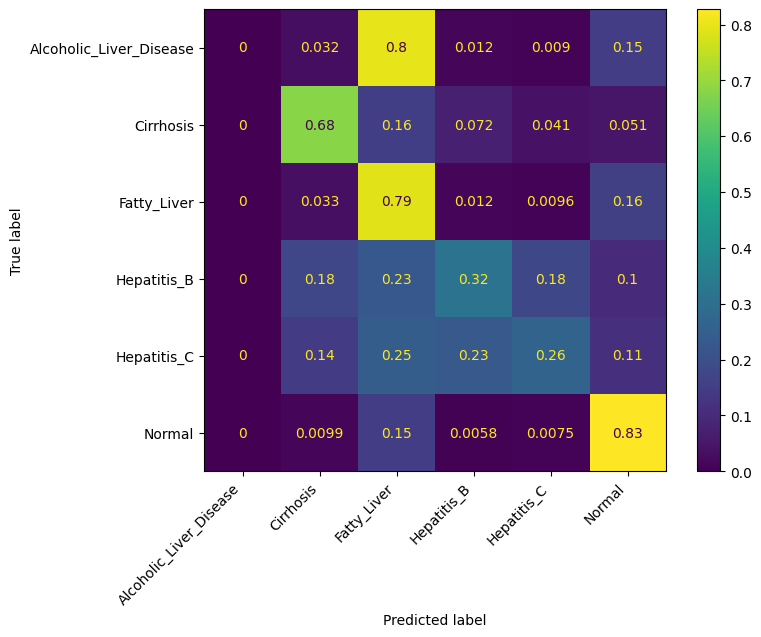

In [6]:
evaluate_pipeline(get_pipeline(BernoulliNB()), X, y)

Так как бернулли работает с бинарными признаками он теряет информацию о величине непрерывных признаков, что критично в медицинских данных

Модель GaussianNB
F1-macro: 0.724 ± 0.003
F1-weighted: 0.790 ± 0.003


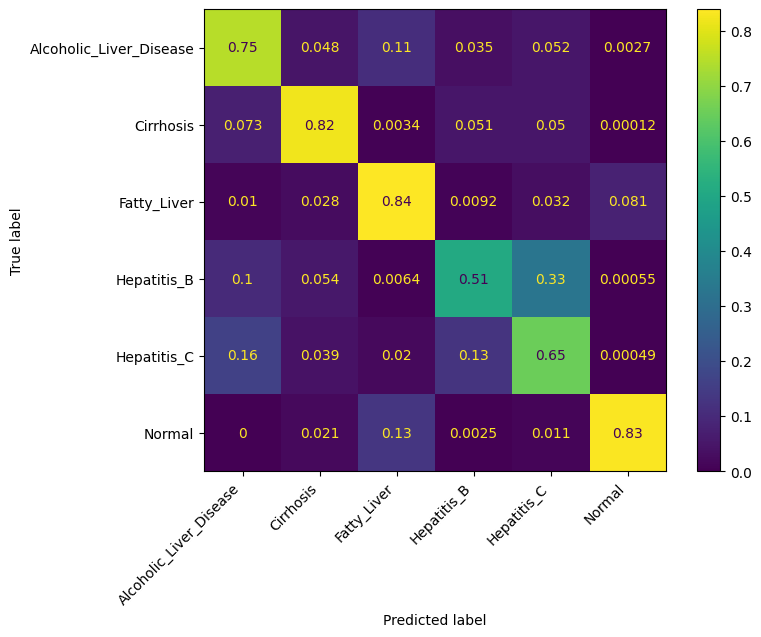

In [7]:
evaluate_pipeline(get_pipeline(GaussianNB()), X, y)

Хотя метод наивного байеса и делает предположение о независимости признаков (что неверно для медицинских данных), в реальном использовании он часто дает хороший результат по нескольким причинам:
1. Классификация требует ранжирования, а не точных вероятностей - нарушение независимости может исказить значения вероятностей, но порядок часто сохраняется
2. Корреляции медицинских данных связаны и работают как множественное подтвержедение гипотезы